In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from losneomrade.profile_retrogression import retrogression_from_profiles
from losneomrade import utils, masks

In [5]:
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString

In [6]:
# bound of the calculation
xmin, xmax, ymin, ymax = 268463.9, 270007.6, 6651396.2, 6652564.4
bounds = (xmin, ymin, xmax, ymax)

In [7]:
dem_data = utils.get_hoydedata(bounds=bounds)
mask = masks.get_msml_mask(bounds=bounds)


In [8]:
# source as numpy array of points:
line_coords = np.array([ (268883.5400622159, 6651785.961672257),
                         (268917.3041989159, 6651614.686395486),
                         (268952.34858209593, 6651598.08903631),
                         (269098.9750438174, 6651692.086224091),
                         (269136.0121169521, 6651688.541504248),
                         (269187.3338556726, 6651662.554160272),
                         (269266.9063958938, 6651685.158933432),
                         (269327.31869611563, 6651689.869289508),
                         (269385.2269397425, 6651692.168949791),
                         (269430.1044651593, 6651718.1729600765),
                         (269417.70676140685, 6651750.211168494),
                         (269417.9726969357, 6651774.200699851),
                         (269471.1996794914, 6651798.455341154),
                         (269514.28554422176, 6651813.7414565245),
                         (269552.6144975672, 6651849.758094928),
                         (269566.83348302596, 6651865.730493411),
                         (269573.36843977927, 6651894.129818862)  ])

In [9]:
# source as a polyline:
source_line = gpd.GeoDataFrame(geometry=[LineString(line_coords)], crs=25833)

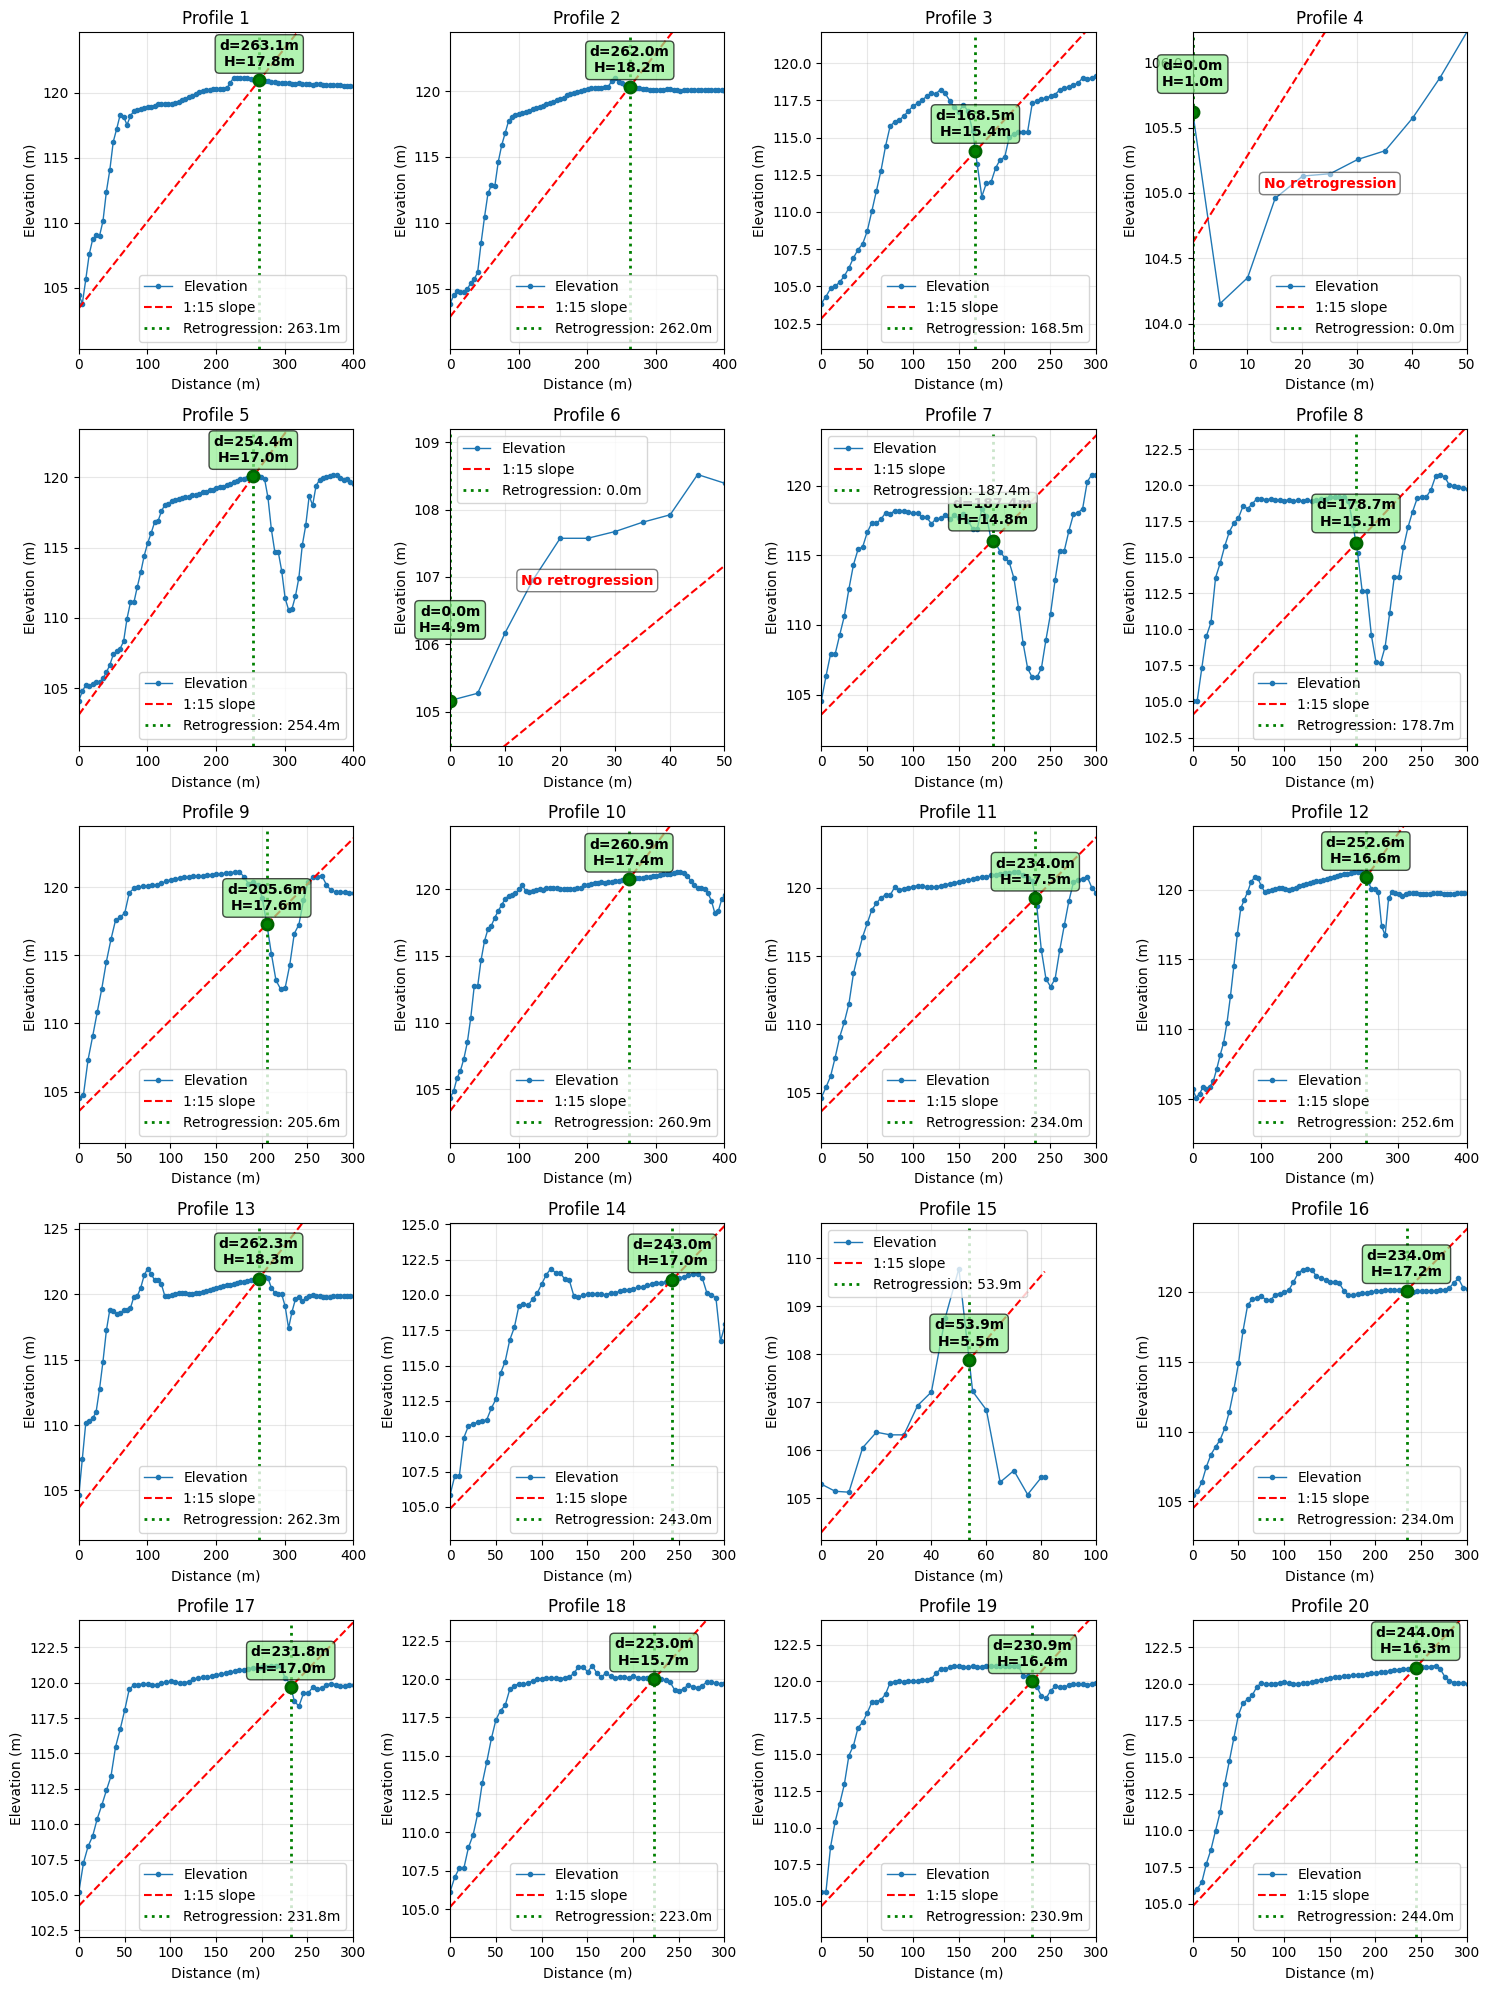

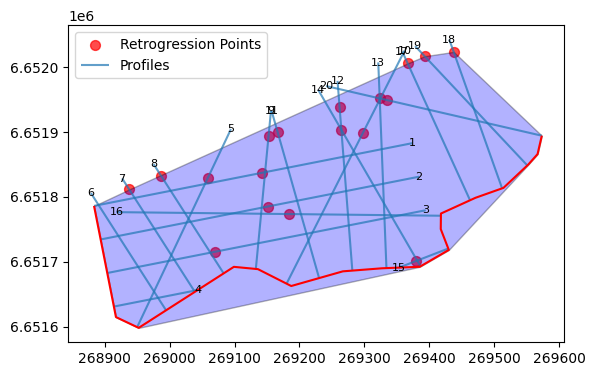

In [10]:
release_gdf_right, debug_layers_right = retrogression_from_profiles(
    line = source_line.geometry.iloc[0],
    dem_array = dem_data["full_array"],
    dem_profile = dem_data["profile"],
    slope_ratio = 1 / 15,
    spacing_m = None,
    n_profiles = 20,
    profile_length_m = 500,
    side = "right",
    depth_m = 1,
    tolerance_distance_m = 75,
    min_height_m = 5,
    max_height_m = 30,
    mask_array = None,
    save_plots_path = None,
    debug = True,
    min_n_points_for_envelope = 3,
    clip_to_sourceline = True,
)

In [11]:
profiles_rg, _, envelope_points_rg, _ = debug_layers_right

In [13]:
from matplotlib.colors import LightSource
import matplotlib.pyplot as plt

def plot_hillshade_with_overlay(dem, transform, crs, polygons_gdf, vertical_exag=1, column=None):


    ls = LightSource(azdeg=315, altdeg=45)
    hillshade = ls.hillshade(dem*vertical_exag)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(hillshade,
              cmap='gray',
              alpha=0.5,
              extent=[
                  transform.c,
                  transform.c + dem.shape[1] * transform.a,
                  transform.f + dem.shape[0] * transform.e,
                  transform.f
              ])

    polygons_gdf = polygons_gdf.to_crs(crs)
    plot_params = {'facecolor': 'red', 'alpha': 0.3, 'edgecolor': 'red', 'linewidth': 0.1}
    polygons_gdf.plot(column=None, legend=True, ax=ax, **plot_params)

    gdf_bounds = polygons_gdf.total_bounds
    ax.set_xlim(np.floor(gdf_bounds[0] / 500) * 500, np.ceil(gdf_bounds[2] / 500) * 500)
    ax.set_ylim(np.floor(gdf_bounds[1] / 500) * 500, np.ceil(gdf_bounds[3] / 500) * 500)

    return fig, ax


<Axes: >

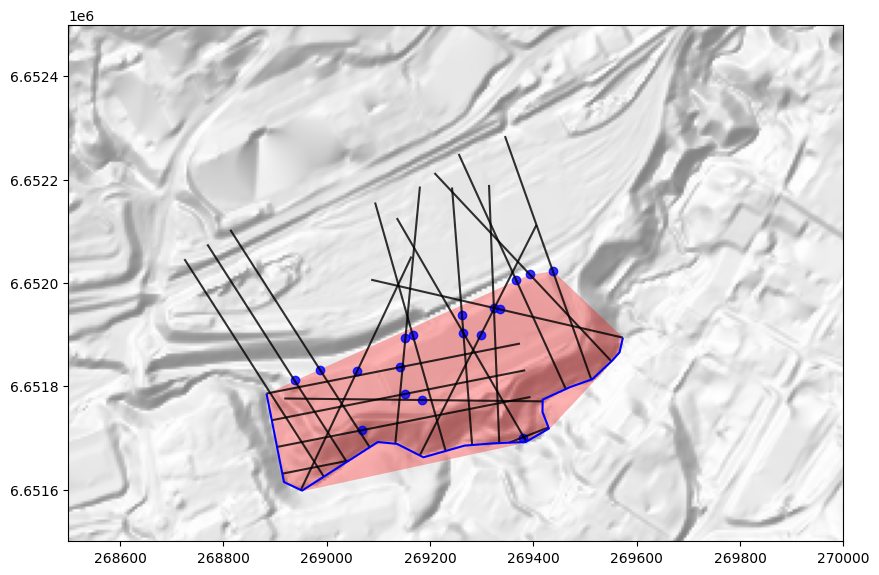

In [16]:
fig, ax = plot_hillshade_with_overlay(dem_data["full_array"], dem_data["profile"]["transform"], 25833, release_gdf_right, vertical_exag=2)

profiles_rg.plot(ax=ax, color="black", alpha=0.8)
envelope_points_rg.plot(ax=ax, color="blue", alpha=0.8)
source_line.plot(ax=ax, color="blue", alpha=1)